<a href="https://colab.research.google.com/github/fanilo-nomena/Prediction_Prix_Voiture/blob/main/PROJET_CARS_PRICE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#importer le ficher csv via google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df= pd.read_csv('/content/drive/MyDrive/used_cars.csv', sep=',')
df.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [4]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [5]:
X= df.drop(['price'], axis=1)
y= df['price']


In [6]:
print(df['clean_title'].unique())

['Yes' nan]


In [7]:
missing_clean_title= df[df['clean_title'].isnull()]
print(missing_clean_title[['model', 'clean_title']].head())

                                           model clean_title
2                                  RX 350 RX 350         NaN
4                      Q3 45 S line Premium Plus         NaN
5                                       ILX 2.4L         NaN
10  Rover Range Rover Sport 3.0 Supercharged HST         NaN
14                                        F-TYPE         NaN


In [8]:
#Changer les valeur maquantes dans clean_title par "Yes"
df['clean_title'] = df['clean_title'].fillna('unknown')
df['clean_title']

,clean_title
0,Yes
1,Yes
2,unknown
3,Yes
4,unknown
...,...
4004,Yes
4005,Yes
4006,unknown
4007,Yes


In [9]:
print(df['fuel_type'].unique())
print(df['fuel_type'].value_counts())

['E85 Flex Fuel' 'Gasoline' 'Hybrid' nan 'Diesel' 'Plug-In Hybrid' '–'
 'not supported']
fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64


In [10]:
#Mettre Gasoline(mode) dans les valeurs manquantes dans fuel_type
df['fuel_type'] = df['fuel_type'].fillna('Gasoline')
df['fuel_type']


,fuel_type
0,E85 Flex Fuel
1,Gasoline
2,Gasoline
3,Hybrid
4,Gasoline
...,...
4004,Gasoline
4005,Gasoline
4006,Gasoline
4007,Gasoline


In [11]:
print(df['accident'].unique())

['At least 1 accident or damage reported' 'None reported' nan]


In [12]:
print(df['accident'].value_counts())

accident
None reported                             2910
At least 1 accident or damage reported     986
Name: count, dtype: int64


In [13]:
# changer les valeurs manquantes dans accident par "Unknown"
df['accident']= df['accident'].fillna('Unknown')
df['accident']


,accident
0,At least 1 accident or damage reported
1,At least 1 accident or damage reported
2,None reported
3,None reported
4,None reported
...,...
4004,None reported
4005,None reported
4006,None reported
4007,None reported


In [14]:
#Verification des doublons
print(df.duplicated().sum())

0


In [15]:
#Description Statistique du prix
print(df['price'].describe())

count        4009
unique       1569
top       $15,000
freq           39
Name: price, dtype: object


In [16]:
#Description Statistique de l'année du model
print(df['model_year'].describe())

count    4009.000000
mean     2015.515590
std         6.104816
min      1974.000000
25%      2012.000000
50%      2017.000000
75%      2020.000000
max      2024.000000
Name: model_year, dtype: float64


In [17]:
# mettre le premier lettre dans la colonne Brand en majuscule
df['brand'] = df['brand'].str.capitalize()
df['brand']


,brand
0,Ford
1,Hyundai
2,Lexus
3,Infiniti
4,Audi
...,...
4004,Bentley
4005,Audi
4006,Porsche
4007,Ford


In [18]:
df['fuel_type'] = df['fuel_type'].str.capitalize()
df['fuel_type']

,fuel_type
0,E85 flex fuel
1,Gasoline
2,Gasoline
3,Hybrid
4,Gasoline
...,...
4004,Gasoline
4005,Gasoline
4006,Gasoline
4007,Gasoline


In [19]:
print(df['price'].unique())


['$10,300' '$38,005' '$54,598' ... '$59,335' '$349,950' '$90,998']


In [20]:
#Changer le prix en Type Float
df['price'] = df['price'].astype(str).str.replace('[\$,€]', '', regex=True).str.replace(',', '').str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')

print(df['price'].describe())

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_2251/2248995090.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].astype(str).str.replace('[\$,€]', '', regex=True).str.replace(',', '').str.strip()


In [21]:
from sklearn.preprocessing import LabelEncoder
#Changer le Type de la colonne Brand
le = LabelEncoder()
df['brand_encoded'] = le.fit_transform(df['brand'])
df['brand_encoded']

,brand_encoded
0,14
1,19
2,27
3,20
4,3
...,...
4004,4
4005,3
4006,43
4007,14


In [22]:
#mettre la colonne model en valeur numerique
le_model = LabelEncoder()
df['model_encoded'] = le_model.fit_transform(df['model'])
df['model_encoded']

,model_encoded
0,1743
1,1182
2,1325
3,1242
4,1225
...,...
4004,484
4005,1464
4006,1677
4007,666


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   brand          4009 non-null   object
 1   model          4009 non-null   object
 2   model_year     4009 non-null   int64 
 3   milage         4009 non-null   object
 4   fuel_type      4009 non-null   object
 5   engine         4009 non-null   object
 6   transmission   4009 non-null   object
 7   ext_col        4009 non-null   object
 8   int_col        4009 non-null   object
 9   accident       4009 non-null   object
 10  clean_title    4009 non-null   object
 11  price          4009 non-null   int64 
 12  brand_encoded  4009 non-null   int64 
 13  model_encoded  4009 non-null   int64 
dtypes: int64(4), object(10)
memory usage: 438.6+ KB


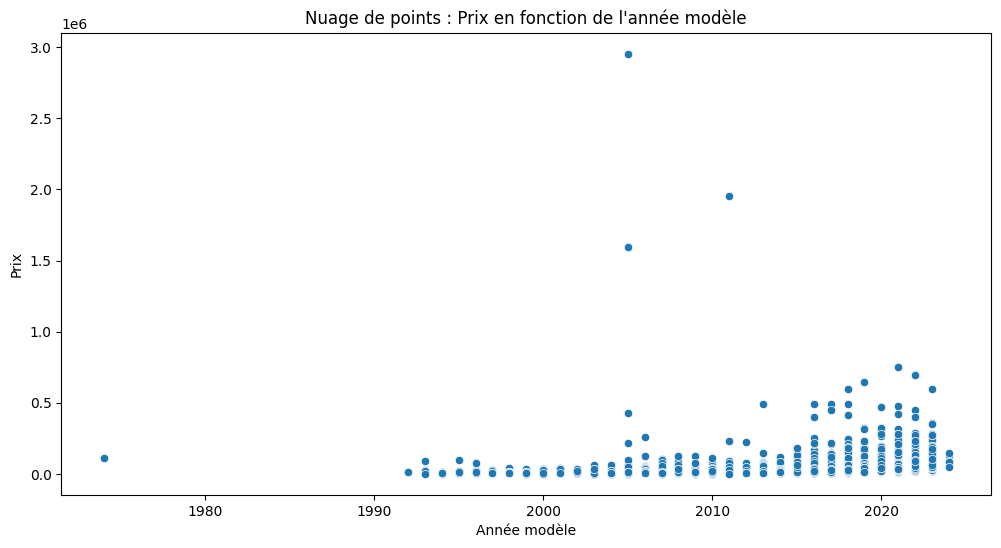

In [24]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.scatterplot(x='model_year', y='price',data= df)
plt.title('Nuage de points : Prix en fonction de l\'année modèle')
plt.xlabel('Année modèle')
plt.ylabel('Prix')
plt.show()

In [25]:
#Separer les features et target
X = df.drop(['price'], axis=1)
y = df['price']


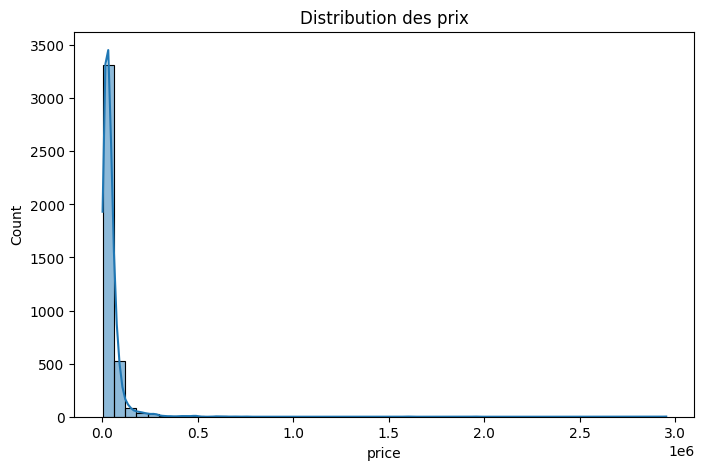

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution des prix")
plt.show()

In [27]:
print(df['fuel_type'].unique())


['E85 flex fuel' 'Gasoline' 'Hybrid' 'Diesel' 'Plug-in hybrid' '–'
 'Not supported']


In [28]:
#Encodage de fa colonne fuel_type (type de carburent)
df.replace({'fuel_type':{'E85 flex fuel':1,'Gasoline':2,'Hybrid':3,'Diesel':4,'Plug-in hybrid':5,'-':6,'Not supported':0}}, inplace=True)

In [29]:
print(df['milage'].unique())

['51,000 mi.' '34,742 mi.' '22,372 mi.' ... '53,705 mi.' '714 mi.'
 '2,116 mi.']


In [30]:
df['milage'] = df['milage'].str.replace('[^0-9.]', '', regex=True).astype(float)
df['milage']

,milage
0,51000.0
1,34742.0
2,22372.0
3,88900.0
4,9835.0
...,...
4004,714.0
4005,10900.0
4006,2116.0
4007,33000.0


In [31]:
df['engine'] = df['engine'].astype(str).str.extract(r'([0-9]+(?:\.[0-9]+)?)').astype(float)
df['engine']

,engine
0,300.0
1,3.8
2,3.5
3,354.0
4,2.0
...,...
4004,6.0
4005,349.0
4006,NaN
4007,450.0


In [32]:
df = df.dropna(subset=['engine'])



In [33]:
print(df['accident'].unique())

['At least 1 accident or damage reported' 'None reported' 'Unknown']


In [34]:
df['accident'] = df['accident'].map({'At least 1 accident or damage reported': 1, 'None reported': 0,'Unknown':2})
df['accident']

,accident
0,1
1,1
2,0
3,0
4,0
...,...
4003,1
4004,0
4005,0
4007,0


In [35]:
print(df['clean_title'].unique())

['Yes' 'unknown']


In [36]:
df['clean_title'] = df['clean_title'].map({'Yes': 1, 'Unknown': 0})
df['clean_title']

,clean_title
0,1.0
1,1.0
2,NaN
3,1.0
4,NaN
...,...
4003,1.0
4004,1.0
4005,1.0
4007,1.0


In [37]:
df['clean_title'] = df['clean_title'].fillna(0)
df['clean_title']

,clean_title
0,1.0
1,1.0
2,0.0
3,1.0
4,0.0
...,...
4003,1.0
4004,1.0
4005,1.0
4007,1.0


In [38]:
# Encodage des colonnes catégorielles
label_cols = ['fuel_type', 'transmission', 'ext_col', 'int_col']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    df[col]

In [39]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['brand', 'model']
le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [40]:
X = df.drop('price',axis=1)  # Features : toutes les colonnes sauf 'price'
y = df['price']

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=2)

In [42]:
#MODEL MACHINE LEARNING
#Regression Lineaire
from sklearn.linear_model import LinearRegression
from sklearn import metrics
model = LinearRegression()
# Train Model
model.fit(X_train, y_train)

LinearRegression()

In [43]:
#Evaluation du performance du model de Regression Lineaire
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 23855.14
RMSE: 43870.77
R²: 0.21


In [44]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 14230.649949174081
RMSE: 33289.525071620024
R²: 0.5444480014180999


In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best MAE:", mean_absolute_error(y_test, y_pred))
print("Best R²:", r2_score(y_test, y_pred))

Best MAE: 14008.414533672172
Best R²: 0.5713477236683415


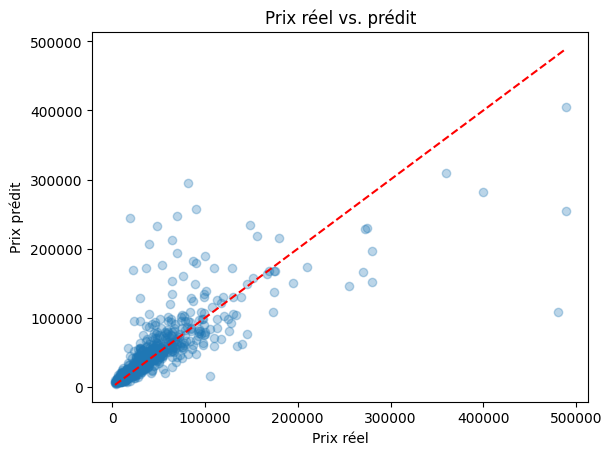

In [46]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Prix réel vs. prédit")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


In [47]:
#XGBoost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [48]:
#Voir la performance du model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

MAE  : 11703.14
RMSE : 28334.32
R²   : 0.67


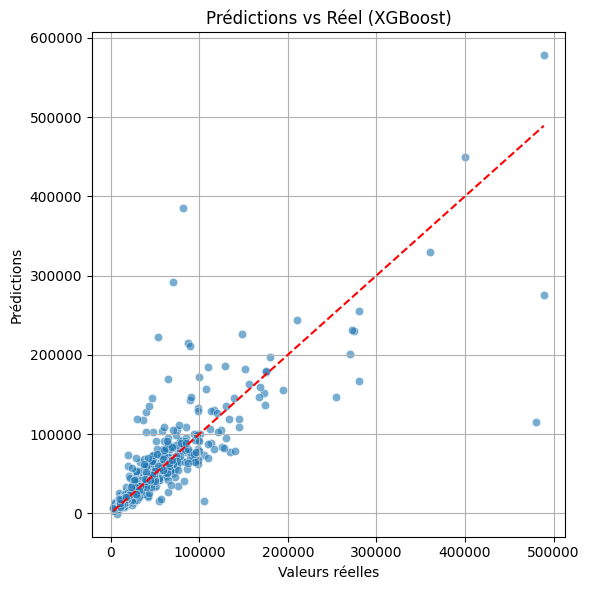

In [49]:
#Visualisation
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Réel (XGBoost)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [50]:
import joblib

# Sauvegarde
joblib.dump(best_model, "modele_voiture.pkl")



['modele_voiture.pkl']

In [51]:
df['price'].mean()

np.float64(44598.35588908675)